# Chapter 12. VQE — H₂ 분자 (양자 데이터)

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- `qml.qchem`으로 분자 Hamiltonian 자동 생성
- 변분 원리에 기반한 VQE 학습
- 결합 길이에 따른 에너지 곡선 그리기 (선택)

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 12.1 H₂ 분자 Hamiltonian 생성
두 수소 원자의 좌표(단위: Bohr)와 활성 전자 정보를 주면 Pauli 합 형태의 Hamiltonian이 만들어진다.

In [2]:
symbols = ['H', 'H']
coordinates = np.array([[0.0, 0.0, -0.7], [0.0, 0.0, 0.7]])

H, n_qubits = qml.qchem.molecular_hamiltonian(
    symbols, coordinates, basis='sto-3g'
)
print(f'사용 큐비트 수: {n_qubits}')
print(f'Hamiltonian 항 수: {len(H.terms()[0])}')

사용 큐비트 수: 4
Hamiltonian 항 수: 15


## 12.2 ansatz 정의
Hartree-Fock 상태에서 출발해 single/double excitation을 적용하는 단순 UCC ansatz.

In [3]:
# 전자 수 (H_2는 2전자)
n_electrons = 2
hf_state = qml.qchem.hf_state(n_electrons, n_qubits)
print(f'Hartree-Fock 상태: {hf_state}')

dev = qml.device('default.qubit', wires=n_qubits)

# 가능한 single/double excitation
singles, doubles = qml.qchem.excitations(n_electrons, n_qubits)
print(f'single excitations: {len(singles)}, double excitations: {len(doubles)}')

@qml.qnode(dev, interface='autograd')
def circuit(params):
    # HF 상태 준비
    qml.BasisState(hf_state, wires=range(n_qubits))
    # 모든 single excitation 적용
    for i, exc in enumerate(singles):
        qml.SingleExcitation(params[i], wires=exc)
    # 모든 double excitation 적용
    for i, exc in enumerate(doubles):
        qml.DoubleExcitation(params[len(singles) + i], wires=exc)
    return qml.expval(H)

n_params = len(singles) + len(doubles)
print(f'총 변분 파라미터 수: {n_params}')

Hartree-Fock 상태: [1 1 0 0]
single excitations: 2, double excitations: 1
총 변분 파라미터 수: 3


## 12.3 VQE 학습

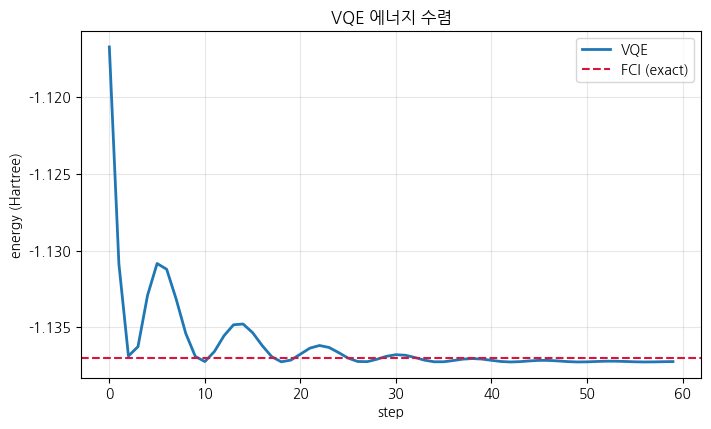

최종 VQE 에너지: -1.137249 Hartree
정확한 값:       -1.137000 Hartree
오차:           2.49e-04 Hartree


In [4]:
params = pnp.zeros(n_params, requires_grad=True)
opt = qml.AdamOptimizer(0.1)

history = []
for step in range(60):
    params, energy = opt.step_and_cost(circuit, params)
    history.append(energy)

# 참고값: FCI 계산 결과 (H_2 / sto-3g, R=1.4 Bohr)
exact = -1.137

plt.figure(figsize=(8, 4.5))
plt.plot(history, lw=2, label='VQE')
plt.axhline(exact, color='crimson', ls='--', label='FCI (exact)')
plt.xlabel('step'); plt.ylabel('energy (Hartree)')
plt.title('VQE 에너지 수렴')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'최종 VQE 에너지: {history[-1]:.6f} Hartree')
print(f'정확한 값:       {exact:.6f} Hartree')
print(f'오차:           {abs(history[-1] - exact):.2e} Hartree')

## 12.4 결합 길이별 에너지 곡선 (potential energy surface)
두 H 원자 사이 거리를 바꿔가며 VQE를 반복 수행하면 분자의 에너지 곡선이 그려진다.

R = 0.60 Bohr → E = -0.6761 Hartree
R = 1.00 Bohr → E = -1.0784 Hartree
R = 1.40 Bohr → E = -1.1365 Hartree
R = 1.80 Bohr → E = -1.1107 Hartree
R = 2.20 Bohr → E = -1.0635 Hartree


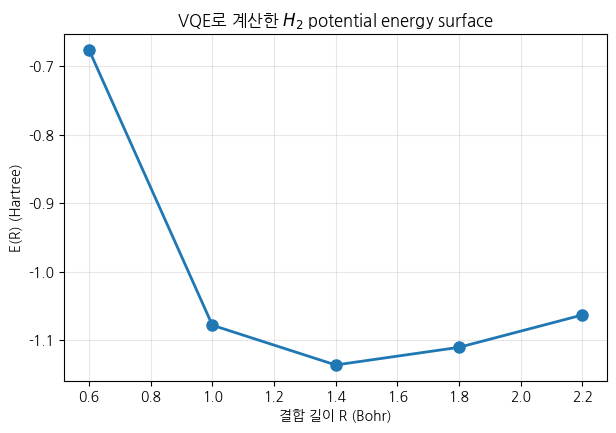

In [5]:
bond_lengths = np.linspace(0.6, 2.2, 5)
energies = []

for r in bond_lengths:
    coords = np.array([[0.0, 0.0, -r / 2], [0.0, 0.0, r / 2]])
    H_r, n_q = qml.qchem.molecular_hamiltonian(symbols, coords, basis='sto-3g')
    dev_r = qml.device('default.qubit', wires=n_q)
    hf = qml.qchem.hf_state(2, n_q)
    sgls, dbls = qml.qchem.excitations(2, n_q)

    @qml.qnode(dev_r, interface='autograd')
    def circ_r(p):
        qml.BasisState(hf, wires=range(n_q))
        for i, e in enumerate(sgls):
            qml.SingleExcitation(p[i], wires=e)
        for i, e in enumerate(dbls):
            qml.DoubleExcitation(p[len(sgls) + i], wires=e)
        return qml.expval(H_r)

    p = pnp.zeros(len(sgls) + len(dbls), requires_grad=True)
    opt_r = qml.AdamOptimizer(0.15)
    for _ in range(25):
        p = opt_r.step(circ_r, p)
    energies.append(float(circ_r(p)))
    print(f'R = {r:.2f} Bohr → E = {energies[-1]:.4f} Hartree')

plt.figure(figsize=(7, 4.5))
plt.plot(bond_lengths, energies, 'o-', lw=2, markersize=8)
plt.xlabel('결합 길이 R (Bohr)'); plt.ylabel('E(R) (Hartree)')
plt.title('VQE로 계산한 $H_2$ potential energy surface')
plt.grid(alpha=0.3)
plt.show()

**관찰.** 결합 길이 약 1.4 Bohr 근처에서 에너지가 최소가 된다 — H₂의 평형 결합 길이다.

## 12.5 정리
- `qml.qchem.molecular_hamiltonian`이 분자 Hamiltonian을 자동 생성한다.
- HF 상태 + excitation ansatz의 조합은 작은 분자에서 매우 효율적이다.
- VQE는 양자 데이터(Hamiltonian)를 직접 다루는 QML의 자연스러운 응용이다.